<style>
.jp-RenderedHTMLCommon p, .rendered_html p {
  text-align: justify;
  line-height: 1.55;
}
.jp-RenderedHTMLCommon table, .rendered_html table {
  font-size: 0.95em;
}
</style>

# IIoT Smart Factory Using ESP8266, MQTT, Sensors and Actuators and Raspberry Pi as our Node-RED Server

## Technical documentation.

**Controller:** NodeMCU ESP8266  
**Communication:** Wi-Fi and MQTT over TLS  
**Broker:** HiveMQ Cloud  
**Supervisory layer:** Node-RED / IIoT dashboard  

### Executive summary

This project implements a small Industrial Internet of Things (IIoT) plant. The
ESP8266 reads temperature, humidity and light intensity; receives four local
push-button commands; operates a DC motor through an L298N H-bridge; displays
robot running/idle states through two LEDs; and exchanges commands and status
information with HiveMQ Cloud using MQTT. Node-RED supervises the plant through MQTT subscriptions and dashboards.
The browser simulation publishes remote-control commands.

The program is event-driven and mostly non-blocking during normal operation.
Separate `millis()` timers schedule LDR sampling, DHT11 publication and MQTT
reconnection, while edge detection and a 50 ms debounce interval prevent one
button press from being processed repeatedly.

> **Security note:** Network passwords, MQTT credentials and the unique broker
> hostname are intentionally not reproduced in this documentation. 

## 1. Assignment

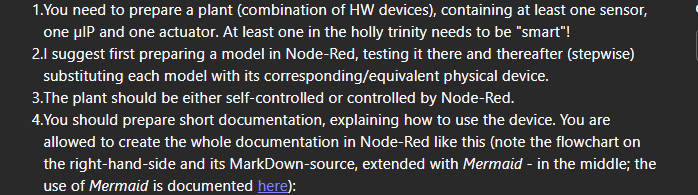

The assignment requires:

1. A plant containing at least one sensor, one input and one actuator.
2. At least one of these three elements to be “smart”.
3. Initial modelling and testing in Node-RED, followed by stepwise substitution
   of model elements with equivalent physical devices.
4. Either self-control or Node-RED control.
5. Documentation explaining how the device is used, including Mermaid diagrams.

## 2. Physical circuit

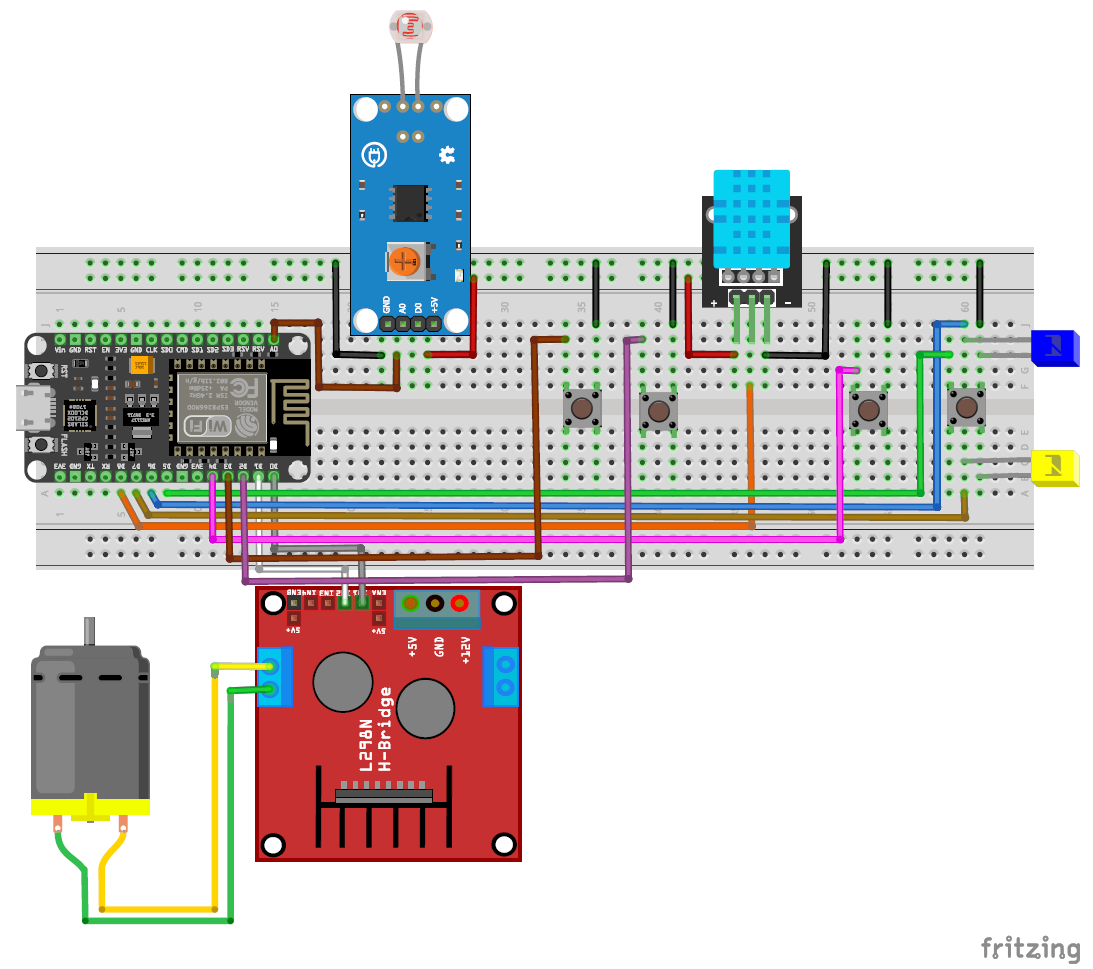

*Figure 2.1: ESP8266-based IIoT circuit with DHT11, LDR module, push buttons, LEDs, L298N motor driver and DC motor.*


### 2.1 Hardware inventory

| Component | Category | Function |
|---|---|---|
| NodeMCU ESP8266 | Smart controller | Executes the control program and provides Wi-Fi/MQTT connectivity |
| DHT11 | Sensor | Measures air temperature and relative humidity |
| LDR module | Sensor | Produces an analogue signal representing ambient light |
| Start/Stop push buttons | Inputs | Provide local conveyor and robot commands |
| L298N H-bridge | Power interface | Allows low-power ESP8266 signals to control the DC motor |
| DC motor | Actuator | Represents the conveyor drive |
| Yellow LED | Output/status indicator | Represents robot operating state |
| Blue LED | Output/status indicator | Represents robot idle/stopped state |
| HiveMQ Cloud | Communication service | Routes MQTT messages between the ESP8266 and Node-RED |
| Node-RED | Supervisory software | Simulates, visualises and remotely controls plant elements |

### 2.2 Pin assignment

| ESP8266 label | ESP8266 GPIO | Connected function | Direction | Electrical/software behaviour |
|---|---:|---|---|---|
| D0 | GPIO16 | L298N IN1 | Output | HIGH while motor runs |
| D1 | GPIO5 | L298N IN2 | Output | Kept LOW for one-direction rotation |
| D2 | GPIO4 | Conveyor Start button | Input | `INPUT_PULLUP`; pressed = LOW |
| D3 | GPIO0 | Conveyor Stop button | Input | `INPUT_PULLUP`; pressed = LOW |
| D4 | GPIO2 | Robot Start button | Input | `INPUT_PULLUP`; pressed = LOW |
| D5 | GPIO14 | Robot Stop button | Input | `INPUT_PULLUP`; pressed = LOW |
| D6 | GPIO12 | Yellow RobotOn LED | Output | HIGH = robot running indication |
| D7 | GPIO13 | Blue RobotOff LED | Output | HIGH = robot idle indication |
| D8 | GPIO15 | DHT11 data | Digital input | Read every 2 seconds |
| A0 | ADC0 | LDR analogue output | Analogue input | Raw value mapped to 0–100% |

 **ENA jumper remains installed**, so the motor runs at
the driver's enabled speed. There is no PWM speed control in this sketch.

> **Hardware caution:** D3, D4 and D8 correspond to ESP8266 boot-configuration
> pins. External modules must not force them to the wrong level during reset.
> If the board fails to boot, verify the attached circuitry and pull-up/pull-down
> behaviour on GPIO0, GPIO2 and GPIO15.

## 3. System relationships

### 3.1 Overall IIoT architecture

```mermaid
flowchart TB
    NR["Node-RED model and dashboard"]
    MQ["HiveMQ Cloud MQTT broker"]
    ESP["ESP8266 smart plant node"]
    IN["Physical inputs and sensors<br/>DHT11, LDR, four buttons"]
    OUT["Physical outputs<br/>L298N + motor, yellow/blue LEDs"]

    NR <-->|"Commands, telemetry and states"| MQ
    MQ <-->|"MQTT over TLS / Wi-Fi"| ESP
    IN -->|"Digital and analogue signals"| ESP
    ESP -->|"GPIO control signals"| OUT
```

This architecture separates the **field layer** (sensors and actuator), the
**control/edge layer** (ESP8266) and the **supervisory layer** (Node-RED). HiveMQ
Cloud is the message broker between the edge and supervisory layers.

### 3.2 Hardware signal relationships

```mermaid
flowchart TB
    CTRL["ESP8266 control program"]
    SENS["Sensors<br/>DHT11 + LDR"]
    BTN["Local inputs<br/>four push buttons"]
    DRIVE["Motor path<br/>D0/D1 → L298N → DC motor"]
    LIGHTS["Robot indication<br/>D6 yellow + D7 blue"]

    SENS -->|"Measurements"| CTRL
    BTN -->|"Active-LOW events"| CTRL
    CTRL -->|"motorRunning state"| DRIVE
    CTRL -->|"Robot state"| LIGHTS
```

## 4. Program organisation

| Program section | Source lines | Responsibility |
|---|---:|---|
| Libraries and DHT object | 1–10 | Enables ESP8266 Wi-Fi, TLS, MQTT and DHT11 support |
| Network and MQTT configuration | 12–43 | Stores connection parameters, topic names and client objects |
| GPIO/state declarations | 45–71 | Assigns physical pins and keeps motor/light state |
| Timers and debounce state | 73–92 | Implements periodic work without blocking the main loop |
| MQTT payload parser and callback | 95–151 | Converts incoming payloads and performs remote actions |
| Wi-Fi and MQTT connection management | 153–208 | Establishes network access and restores broker subscriptions |
| Publishing helpers | 210–243 | Publishes strings, integers, floats and periodic states |
| `setup()` | 245–279 | Configures safe initial outputs, inputs, sensors and communication |
| `loop()` | 281–393 | Services MQTT, sensors, buttons, motor output and telemetry |

### 4.1 Libraries

```cpp
#include <ESP8266WiFi.h>      // Wi-Fi connection
#include <WiFiClientSecure.h> // TLS transport
#include <PubSubClient.h>     // MQTT client
#include <DHT.h>              // DHT11 sensor
```

`WiFiClientSecure` creates the encrypted TCP transport, while `PubSubClient`
implements MQTT on top of that transport. The DHT object is configured for a
DHT11 on D8. Connection secrets are deliberately omitted from this
documentation.

## 5. Flowchart 1 — startup and initialization

`setup()` first places the physical outputs in safe states. Only after the motor
pins and LEDs have been configured does it start the DHT sensor, connect to
Wi-Fi and configure MQTT.

```mermaid
flowchart TD
    A([Power on / reset]) --> B["Start Serial at 115200 baud"]
    B --> C["Configure robot buttons as INPUT_PULLUP"]
    C --> D["Configure yellow and blue LEDs as outputs"]
    D --> E["Configure D0 and D1 as motor outputs"]
    E --> F["Configure conveyor buttons as INPUT_PULLUP"]
    F --> G["Force motor outputs LOW"]
    G --> H["Start DHT11"]
    H --> I["Connect to Wi-Fi"]
    I --> J["Configure TLS and MQTT server"]
    J --> K["Register mqttCallback"]
    K --> L([Enter loop])
```

Important behaviours:

- The conveyor is OFF at power-up because both motor direction pins are LOW.
- All four buttons use internal pull-up resistors, so an unpressed button reads
  HIGH and a pressed button reads LOW.
- The code calls `espClient.setInsecure()`. Traffic is encrypted, but the broker
  certificate is not authenticated. This is acceptable only for a controlled
  demonstration; production code should verify the broker certificate.
- `setup_wifi()` waits in a loop until Wi-Fi connects. Startup is therefore
  blocking, even though normal loop scheduling is mostly non-blocking.

## 6. Flowchart 2 — MQTT connection and remote commands

### 6.1 Connection management

When MQTT is disconnected, `reconnect()` permits one attempt every 5 seconds.
After a successful connection, the program subscribes again because MQTT
subscriptions must be restored after a new session.

```mermaid
flowchart TD
    A["loop calls reconnect"] --> B{"MQTT already connected?"}
    B -->|Yes| Z([Return])
    B -->|No| C{"5 s since last attempt?"}
    C -->|No| Z
    C -->|Yes| D["Create unique client ID"]
    D --> E["Connect using MQTT credentials"]
    E --> F{"Connection successful?"}
    F -->|No| G["Print error; retry later"]
    G --> Z
    F -->|Yes| H["Subscribe to four command topics"]
    H --> I["Print subscription results"]
    I --> Z
```

### 6.2 MQTT callback

`mqttCommandIsTrue()` makes command handling tolerant of several positive
payloads: `true`, `1`, `on`, `start` or `pressed`, without regard to letter
case. Any other payload is ignored. The callback then compares the topic and
updates the appropriate state or outputs.

```mermaid
flowchart TD
    A["MQTT message arrives"] --> B["Normalise payload text"]
    B --> C{"Payload means active?"}
    C -->|No| Z([Ignore message])
    C -->|Yes| D{"Which command topic?"}
    D -->|Robot start| E["Yellow ON; blue OFF<br/>publish robot states"]
    D -->|Robot stop| F["Yellow OFF; blue ON<br/>publish robot states"]
    D -->|Conveyor start| G["motorRunning = true<br/>publish MotorState = 1"]
    D -->|Conveyor stop| H["motorRunning = false<br/>publish MotorState = 0"]
    E --> Z
    F --> Z
    G --> Z
    H --> Z
```

The callback changes `motorRunning`; the main loop then converts that state into
actual GPIO output. Robot commands directly update the two status LEDs.

## 7. Flowchart 3 — main loop scheduler

The `loop()` function is a cooperative scheduler. Each pass is short, and time
tests decide whether slower tasks are due.

```mermaid
flowchart TD
    A([Start loop pass]) --> B{"MQTT connected?"}
    B -->|No| C["Attempt timed reconnect"]
    B -->|Yes| D["Service client.loop"]
    C --> D
    D --> E["Read millis"]
    E --> F["Run LDR task if 500 ms elapsed"]
    F --> G["Process conveyor button edges"]
    G --> H["Apply motorRunning to D0/D1"]
    H --> I["Process robot button edges"]
    I --> J["Run DHT and publish task if 2 s elapsed"]
    J --> K([Repeat immediately])
```

`client.loop()` is essential: it receives subscribed messages, invokes
`mqttCallback()` and maintains the MQTT connection. Long delays inside the main
loop would reduce control responsiveness and could cause broker disconnections.

## 8. Flowchart 4 — sensors and periodic telemetry

### 8.1 LDR conversion

Every 500 ms the ESP8266 reads A0. The measured raw value is mapped from the
calibrated range 120–890 to 0–100 and then constrained so the published
percentage can never be below 0 or above 100.

The conversion is:

$$
L_{\%}=\operatorname{constrain}\left(
\frac{L_{raw}-120}{890-120}\times100,0,100\right)
$$

The last calculated percentage is published every 2 seconds.

### 8.2 DHT11 and telemetry flow

```mermaid
flowchart TD
    A{"500 ms elapsed?"} -->|Yes| B["Read A0"]
    B --> C["Map 120…890 to 0…100"]
    C --> D["Constrain result"]
    D --> E["Store lightintensity"]
    A -->|No| F{"2 s elapsed?"}
    E --> F
    F -->|No| Z([Continue loop])
    F -->|Yes| G["Read temperature and humidity"]
    G --> H{"Both readings valid?"}
    H -->|No| I["Print DHT error"]
    H -->|Yes| J["Publish temperature and humidity"]
    I --> K["Publish motor state and latest light value"]
    J --> K
    K --> Z
```

`publishFloatValue()` formats DHT readings to two decimal places.
`publishIntValue()` formats the light percentage as an integer. All publishing
helpers first check that MQTT is connected; measurements are not buffered while
offline.

## 9. Flowchart 5 — local conveyor control

The Start and Stop buttons are active LOW. A command is accepted only on a
HIGH-to-LOW transition and only if at least 50 ms has passed since the last
accepted press of that button.

```mermaid
flowchart TD
    A["Read Start and Stop buttons"] --> B{"New debounced Start press?"}
    B -->|Yes| C["motorRunning = true"]
    C --> D["Publish StartButton = 1<br/>and MotorState = 1"]
    B -->|No| E{"New debounced Stop press?"}
    D --> E
    E -->|Yes| F["motorRunning = false"]
    F --> G["Publish StopButton = 1<br/>and MotorState = 0"]
    E -->|No| H["Save current button states"]
    G --> H
    H --> I{"motorRunning?"}
    I -->|Yes| J["D0 HIGH; D1 LOW<br/>motor turns"]
    I -->|No| K["D0 LOW; D1 LOW<br/>motor stops"]
```

Only a new press publishes `StartButton` or `StopButton`; holding a button does
not flood the broker. `MotorState` is also republished every 2 seconds to provide
a periodic status update.

## 10. Flowchart 6 — local robot-status control

In this implementation, “robot control” changes two LEDs that represent robot
state. It does not drive a physical robot motor. The yellow output indicates
operation; the blue output indicates idle/stopped.

```mermaid
flowchart TD
    A["Read Robot Start and Stop buttons"] --> B{"New debounced Start press?"}
    B -->|Yes| C["Blue LED OFF<br/>Yellow LED ON"]
    C --> D["Publish StartRobot = 1<br/>and StopRobot = 0"]
    B -->|No| E{"New debounced Stop press?"}
    D --> E
    E -->|Yes| F["Blue LED ON<br/>Yellow LED OFF"]
    F --> G["Publish StopRobot = 1<br/>and StartRobot = 0"]
    E -->|No| H["Save current button states"]
    G --> H
    H --> I([Continue loop])
```

Publishing complementary values (`1/0`) makes the two-state relationship
explicit to Node-RED. The same LED behaviour can also be triggered by remote
MQTT commands.

## 11. MQTT interface

### 11.1 Published topics: ESP8266 → broker → Node-RED

| Topic | Payload | Trigger/frequency | Meaning |
|---|---|---|---|
| `room/temperature` | Decimal °C | Every 2 s when DHT reading is valid | Room temperature |
| `room/humidity` | Decimal %RH | Every 2 s when DHT reading is valid | Relative humidity |
| `room/LightIntensity` | Integer 0–100 | Every 2 s | Mapped light intensity |
| `room/MotorState` | `1` or `0` | On command and every 2 s | Conveyor motor running/stopped |
| `room/StartButton` | `1` | New physical Start press | Conveyor start event |
| `room/StopButton` | `1` | New physical Stop press | Conveyor stop event |
| `room/StartRobot` | `1` or `0` | Physical or remote robot command | Robot-running status |
| `room/StopRobot` | `1` or `0` | Physical or remote robot command | Robot-stopped status |

### 11.2 Subscribed topics: browser commands → broker → ESP8266

| Topic | Accepted active payloads | Action |
|---|---|---|
| `factory/room1/robot/start` | `true`, `1`, `on`, `start`, `pressed` | Yellow ON, blue OFF |
| `factory/room1/robot/stop` | Same | Yellow OFF, blue ON |
| `room/StartButton` | Same | Set `motorRunning = true` |
| `room/StopButton` | Same | Set `motorRunning = false` |

### 11.3 Topic relationship diagram

```mermaid
flowchart TB
    SIM["Browser simulation"]
    BR["HiveMQ Cloud"]
    DEV["ESP8266"]
    DASH["Node-RED dashboards"]

    SIM -->|"Publish remote commands"| BR
    BR -->|"Subscribed commands"| DEV
    DEV -->|"Publish measurements and states"| BR
    BR -->|"Telemetry and feedback"| DASH
    BR -->|"Telemetry and feedback"| SIM
```

The conveyor uses the same topic names for physical-button events and remote
commands. A physical publication can therefore be received again by the same
device because it subscribes to that topic. The resulting command is
idempotent—it repeats the same requested state—but separate `.../cmd` and
`.../state` topic families would give clearer production semantics.

## 12. Timing, state and control behaviour

### 12.1 Timing table

| Mechanism | Interval | Purpose |
|---|---:|---|
| LDR timer | 500 ms | Refresh the stored light percentage |
| DHT/telemetry timer | 2000 ms | Read DHT11 and publish periodic values |
| MQTT reconnect timer | 5000 ms | Limit connection attempts while offline |
| Button debounce | 50 ms | Reject contact bounce and duplicate edge events |

The subtraction form `currentMillis - previousMillis >= interval` remains valid
when the unsigned `millis()` counter wraps around.

### 12.2 Conveyor state table

| Event | `motorRunning` | D0 | D1 | Motor |
|---|---:|---:|---:|---|
| Startup | `false` | LOW | LOW | Stopped |
| Local or MQTT Start | `true` | HIGH | LOW | Running forward |
| Local or MQTT Stop | `false` | LOW | LOW | Stopped |

### 12.3 Robot indication state table

| Event | Yellow `RobotOn` | Blue `RobotOff` | Published pair |
|---|---:|---:|---|
| Startup | LOW | LOW | None |
| Local or MQTT Start | HIGH | LOW | `StartRobot=1`, `StopRobot=0` |
| Local or MQTT Stop | LOW | HIGH | `StartRobot=0`, `StopRobot=1` |

Both LEDs are initially OFF. If an explicit idle indication is desired at
power-up, the program would need to initialise blue HIGH; that is not the
behaviour of the supplied source.

## 13. Operating procedure

### 13.1 Before power-up

1. Confirm all ESP8266-side signals use the board's safe logic voltage.
2. Confirm the ESP8266, sensors and L298N logic side share a common ground.
3. Power the DC motor through the L298N motor supply, not through an ESP8266 pin.
4. Confirm the L298N ENA jumper is installed because the program does not drive
   an enable/PWM pin.
5. Copy `secrets.example.h` to `secrets.h` beside the sketch and fill in
   private Wi-Fi and MQTT settings locally. Never publish `secrets.h`.

### 13.2 Start-up

1. Upload the sketch and open the Serial Monitor at 115200 baud.
2. Reset the ESP8266.
3. Wait for the Wi-Fi-connected message and assigned IP address.
4. Wait for the MQTT-connected message and four successful subscriptions.
5. Open the Node-RED dashboard.

### 13.3 Local operation

- Press the conveyor **Start** button: the motor starts and the start event plus
  running state are published.
- Press the conveyor **Stop** button: the motor stops immediately and the stop
  event plus stopped state are published.
- Press **Robot Start**: yellow turns ON, blue turns OFF and robot status is
  published.
- Press **Robot Stop**: yellow turns OFF, blue turns ON and robot status is
  published.
- Vary light at the LDR and observe `room/LightIntensity`.
- Observe DHT11 temperature and humidity every 2 seconds.

### 13.4 Remote operation

Remote operation closes the IIoT loop between the browser simulation, HiveMQ Cloud, the physical ESP8266 system and the Node-RED monitoring dashboard. The browser uses MQTT over a secure WebSocket (`wss://`), whereas the ESP8266 uses its own MQTT-over-TLS connection. Both clients exchange messages through HiveMQ; the browser does not connect directly to the physical controller.

A remote command follows this sequence:

1. The operator presses a START or STOP control in the Smart Factory simulation.
2. The HTML program publishes payload `1` to the command topic.
3. HiveMQ routes the message to every subscribed client, including the ESP8266.
4. The ESP8266 changes the actuator or status output and publishes feedback.
5. The simulation and Node-RED receive the feedback and update their displays.


#### 13.4.1 Connecting the simulation to HiveMQ by WebSocket

The HTML loads MQTT.js and creates a secure browser-to-broker connection. The
following readable extract is taken from the minified Smart Factory HTML; its
variable names have been expanded and all private connection values have been
replaced with placeholders.

```html
<script src="https://unpkg.com/mqtt/dist/mqtt.min.js"></script>
```

```javascript
const broker = {
  host: "<HiveMQ-host>",
  port: 8884,
  path: "/mqtt",
  username: "<MQTT-username>",
  password: "<MQTT-password>",
  clientId: `threejs_factory_panel_${Math.random().toString(16).slice(2, 10)}`
};

const mqttUrl = `wss://${broker.host}:${broker.port}${broker.path}`;

const mqttClient = window.mqtt.connect(mqttUrl, {
  username: broker.username,
  password: broker.password,
  clientId: broker.clientId,
  clean: true,
  reconnectPeriod: 3000,
  connectTimeout: 10000
});
```

`wss://` encrypts the WebSocket connection between the web browser and HiveMQ.
`clean: true` starts a fresh MQTT session, `reconnectPeriod` retries the
connection every three seconds, and `connectTimeout` cancels an unsuccessful
attempt after ten seconds.

> **Security:** Do not show the real hostname, username or password in the
> report or public HTML. The credentials found in the supplied HTML are not
> reproduced in this notebook and should be rotated before the project is
> shared.


#### 13.4.2 Subscribing to physical-system messages

After the WebSocket connection is established, the simulation subscribes to
sensor readings, machine states and physical-button events.

```javascript
mqttClient.on("connect", () => {
  mqttConnected = true;

  mqttClient.subscribe([
    "room/StartRobot",
    "room/StopRobot",
    "room/temperature",
    "room/humidity",
    "room/LightIntensity",
    "room/MotorState",
    "room/StartButton",
    "room/StopButton"
  ], { qos: 0 });
});

mqttClient.on("message", handleMqttMessage);
mqttClient.on("close", () => { mqttConnected = false; });
mqttClient.on("error", (error) => console.error("MQTT error:", error));
```

| Subscribed topic | Information received by the simulation |
|---|---|
| `room/temperature` | DHT11 temperature |
| `room/humidity` | DHT11 relative humidity |
| `room/LightIntensity` | LDR value mapped to 0–100% |
| `room/MotorState` | Conveyor running (`1`) or stopped (`0`) |
| `room/StartButton` / `room/StopButton` | Physical conveyor-button events |
| `room/StartRobot` / `room/StopRobot` | Physical or remote robot-state feedback |

QoS 0 is used for low-latency live updates. It does not guarantee delivery, but
the periodic telemetry and later status messages refresh the dashboard if one
message is lost.


#### 13.4.3 Processing subscribed MQTT messages

The original HTML normalises raw text and JSON payloads before testing whether
they represent an active or inactive value. The shortened extract below shows
the IIoT decision logic without the minified variable names.

```javascript
function handleMqttMessage(topic, payload) {
  const active = isActive(payload);     // 1, true, on, start, pressed or high
  const inactive = isInactive(payload); // 0, false, off, stop, released or low

  if (topic === "room/StartRobot" && active) startRobot("mqtt");
  if (topic === "room/StopRobot" && active) stopRobot("mqtt");

  if (topic === "room/temperature") updateReading("temperature", payload);
  if (topic === "room/humidity") updateReading("humidity", payload);
  if (topic === "room/LightIntensity") updateReading("lightIntensity", payload);

  if (topic === "room/MotorState") {
    if (active) updateConveyorState(true);
    if (inactive) updateConveyorState(false);
  }

  if (topic === "room/StartButton" && active) {
    startConveyor("mqtt");
    updateConveyorState(true);
  }

  if (topic === "room/StopButton" && (active || inactive)) {
    stopConveyor("mqtt");
    updateConveyorState(false);
  }
}
```

Passing `"mqtt"` to the machine functions identifies the action as a received
broker message. Only actions originating from the simulation control panel are
published again. This prevents a feedback message from creating an endless
publish/subscribe loop.


#### 13.4.4 Publishing remote commands to the physical system

The simulation maps each control-panel event to an MQTT topic and publishes
payload `1` with QoS 0 and no retained message.

```javascript
const commandTopics = {
  robot: {
    START: "factory/room1/robot/start",
    STOP:  "factory/room1/robot/stop"
  },
  pick_place: {
    START: "factory/room1/robot/start",
    STOP:  "factory/room1/robot/stop"
  },
  conveyor: {
    START: "room/StartButton",
    STOP:  "room/StopButton"
  }
};

function publishControl(machine, action) {
  const topic = commandTopics[machine]?.[action.toUpperCase()];

  if (topic && mqttClient && mqttConnected) {
    mqttClient.publish(topic, "1", { qos: 0, retain: false });
  }
}
```

The machine-control functions publish only when the action starts at the
simulation panel:

```javascript
function startRobot(source = "panel") {
  // Start the simulated pick-and-place cycle.
  if (source === "panel") publishControl("pick_place", "START");
}

function startConveyor(source = "panel") {
  // Start the simulated conveyor.
  if (source === "panel") publishControl("conveyor", "START");
}
```

| Simulation action | Published topic | Physical effect after HiveMQ routing |
|---|---|---|
| Robot START | `factory/room1/robot/start` | Robot-running LED/state becomes active |
| Robot STOP | `factory/room1/robot/stop` | Robot-idle LED/state becomes active |
| Conveyor START | `room/StartButton` | ESP8266 starts the conveyor motor |
| Conveyor STOP | `room/StopButton` | ESP8266 stops the conveyor motor |

The browser publishes to HiveMQ, not directly to the ESP8266. HiveMQ routes
the command to the physical controller because it subscribes to the same
topic. The Node-RED export also monitors `factory/room1/conveyor/start` and
`factory/room1/conveyor/stop` for dashboard state, but does not republish them
as motor commands. Physical conveyor control uses `room/StartButton` and
`room/StopButton` in the bundled firmware.


#### 13.4.5 Node-RED JSON flow summary

The bundled `Smart_Factory_Flows.json` contains **67 Node-RED objects** across
three flow tabs: Stade DWD AI Weather, Actuators and Sensors, and Smart Factory.
The Smart Factory tab has 13 runtime nodes: nine MQTT inputs, two change nodes,
one state-aggregation function and one dashboard template. Seven MQTT broker
configuration nodes are also included in the complete export.

All live messages ultimately pass through `Aggregate Smart Factory State`.
This function preserves the last valid values in the flow context under
`smartFactoryDashboardState`, converts sensor payloads to numbers, accepts
common Boolean forms such as `1`, `true`, `start`, `running`, `0`, `false`,
`stop` and `idle`, and emits one consistent dashboard object.

| Flow | MQTT input topic(s) | Processing performed | Dashboard result |
|---|---|---|---|
| 1. Temperature telemetry | `room/temperature` | Convert the DHT11 payload to a number and store it as `temperature`. | Temperature gauge |
| 2. Humidity telemetry | `room/humidity` | Convert the DHT11 payload to a number and store it as `humidity`. | Humidity gauge |
| 3. Light telemetry | `room/LightIntensity` | Convert the LDR payload to a number and store it as `light`. | Light-intensity gauge |
| 4. Robot state | `room/StartRobot`, `room/StopRobot` | A true start event sets `robot = true`; a true stop event sets `robot = false`. | Pick-and-place status, LED text and operation state |
| 5. Local conveyor events | `room/StartButton`, `room/StopButton` | Start sets `conveyor = true`; stop sets `conveyor = false`. | Conveyor running/stopped state |
| 6. Simulation compatibility | `factory/room1/conveyor/start`, `factory/room1/conveyor/stop` | Two change nodes rewrite the topics to `room/StartButton` and `room/StopButton`, allowing simulation commands to reuse the same state logic. | Simulation and physical-button events behave identically |

After processing any of these flows, the function adds the update time and
source topic, changes the outgoing topic to `smart-factory/state`, and sends
the following object to the dashboard template:

```javascript
{
  temperature,
  humidity,
  light,
  robot,
  conveyor,
  robotEvent,
  conveyorEvent,
  updatedAt,
  source
}
```

The `Smart Factory Dashboard` UI template turns this object into three sensor
gauges, two machine-state cards, the Live MQTT indicator, the last-update time
and the last received topic. The exported JSON contains MQTT input nodes but no MQTT
output node; therefore, this Node-RED flow is a **monitoring and visualisation
layer**. Commands are published by the browser simulation or generated by the
physical controls.

```mermaid
flowchart TB
    ENV["Environmental topics<br/>temperature, humidity and light"]
    ROB["Robot topics<br/>StartRobot and StopRobot"]
    LOCAL["Local conveyor topics<br/>StartButton and StopButton"]
    SIM["Simulation conveyor topics<br/>factory/room1/conveyor/start and stop"]
    MAP["Two change nodes<br/>rewrite simulation topics"]
    AGG["Aggregate Smart Factory State<br/>normalise, retain and timestamp"]
    UI["UI template<br/>gauges, machine cards and MQTT status"]

    ENV --> AGG
    ROB --> AGG
    LOCAL --> AGG
    SIM --> MAP --> AGG
    AGG --> UI
```

*Figure 13.4.1: Internal Node-RED paths represented by the supplied JSON flow.*


#### 13.4.6 Entity relationship

```mermaid
erDiagram
    SMART_FACTORY_SIMULATION {
        string transport "MQTT over secure WebSocket"
        string role "Publish commands and mirror plant state"
    }
    HIVEMQ_BROKER {
        string role "Authenticate clients and route topics"
        string protocol "MQTT"
    }
    PHYSICAL_ESP8266_SYSTEM {
        string inputs "DHT11, LDR and push buttons"
        string outputs "Motor driver, motor and status LEDs"
    }
    NODE_RED_MONITORING {
        string input "MQTT subscriptions"
        string output "Dashboard state"
    }
    MQTT_MESSAGE {
        string topic
        string payload
        int qos
    }

    SMART_FACTORY_SIMULATION }o--|| HIVEMQ_BROKER : connects_by_WSS
    PHYSICAL_ESP8266_SYSTEM }o--|| HIVEMQ_BROKER : connects_by_TLS
    NODE_RED_MONITORING }o--|| HIVEMQ_BROKER : subscribes_to
    HIVEMQ_BROKER ||--o{ MQTT_MESSAGE : routes
```

*Figure 13.4.2: Entity relationship among the Smart Factory simulation, HiveMQ,
the physical ESP8266 system, Node-RED and the exchanged MQTT messages.*

#### 13.4.7 End-to-end IIoT message flow

```mermaid
flowchart TB
    SIM["Smart Factory simulation<br/>HTML + Three.js + MQTT.js"]
    MQ["HiveMQ Cloud<br/>MQTT broker"]
    DEV["Physical system<br/>ESP8266, sensors and actuators"]
    NR["Node-RED monitoring<br/>State aggregation + dashboard"]

    SIM -->|"Publish START/STOP commands by WSS"| MQ
    MQ -->|"Route subscribed commands"| DEV
    DEV -->|"Publish telemetry, events and states"| MQ
    MQ -->|"Update subscribed simulation state"| SIM
    MQ -->|"Feed MQTT input nodes"| NR
```

*Figure 13.4.3: Remote-operation data flow. HiveMQ decouples the simulation,
physical plant and monitoring dashboard.*


#### 13.4.8 Evidence from the implemented Smart Factory

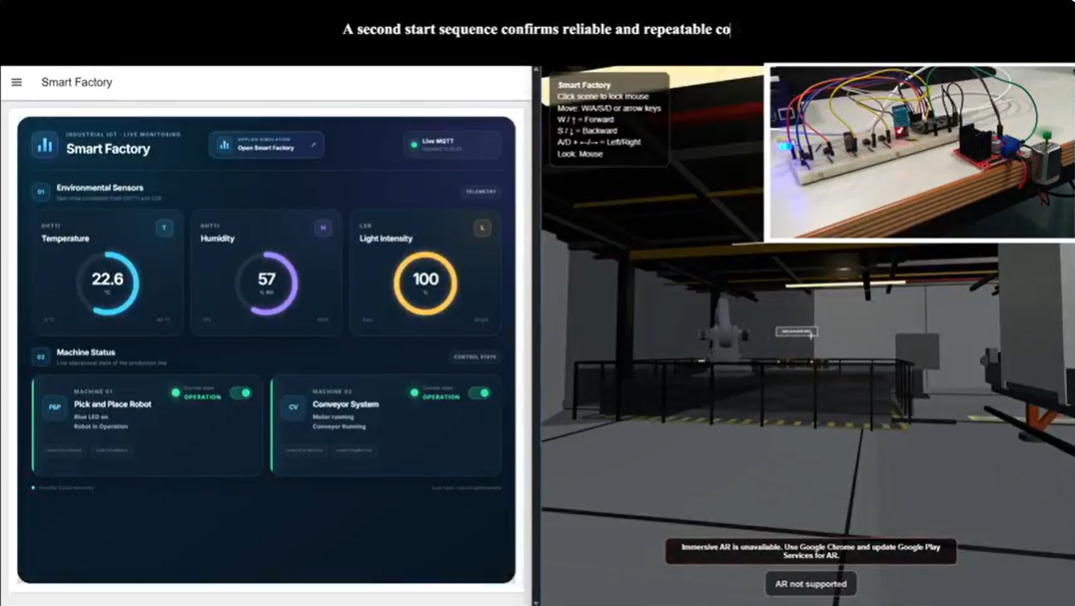

*Figure 13.4.4: Integrated Smart Factory view showing the Node-RED monitoring
dashboard on the left, the Three.js factory simulation on the right and the
physical ESP8266 circuit in the inset.*

Figure 13.4.4 demonstrates the complete monitoring relationship. The physical
ESP8266 publishes temperature, humidity, light intensity and machine states to
HiveMQ. Node-RED subscribes to these topics and displays the latest values,
while the browser simulation mirrors the robot and conveyor operation. In the
captured state, the dashboard shows live MQTT data and both machines in
operation, providing visual evidence that the digital and physical parts share
the same IIoT state.

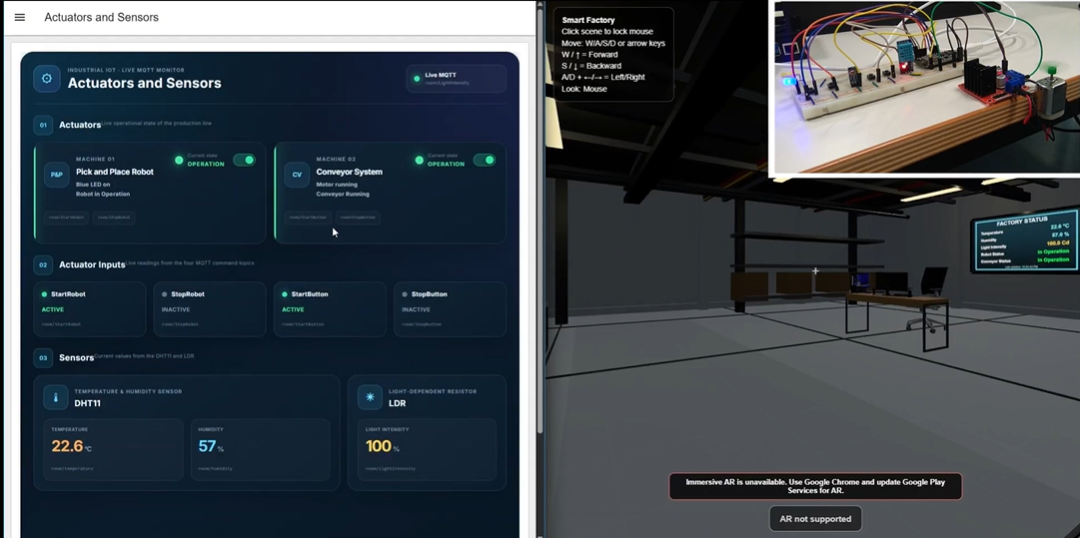

*Figure 13.4.5: Actuators-and-sensors view showing machine states, MQTT input
events, DHT11/LDR readings, the Smart Factory simulation and the physical
ESP8266 node.*

Figure 13.4.5 separates the data into three operational layers:

1. **Actuators:** the robot and conveyor cards show whether each machine is in
   operation.
2. **Actuator inputs:** `StartRobot`, `StopRobot`, `StartButton` and
   `StopButton` reveal which MQTT event is active.
3. **Sensors:** the DHT11 temperature and humidity and the LDR light intensity
   show the latest telemetry published by the ESP8266.

The combined image is useful for system validation because an operator can
compare the Node-RED state, the corresponding motion in the simulation and the
LED/motor response on the physical circuit at the same time.


#### 13.4.9 AI weather-prediction system

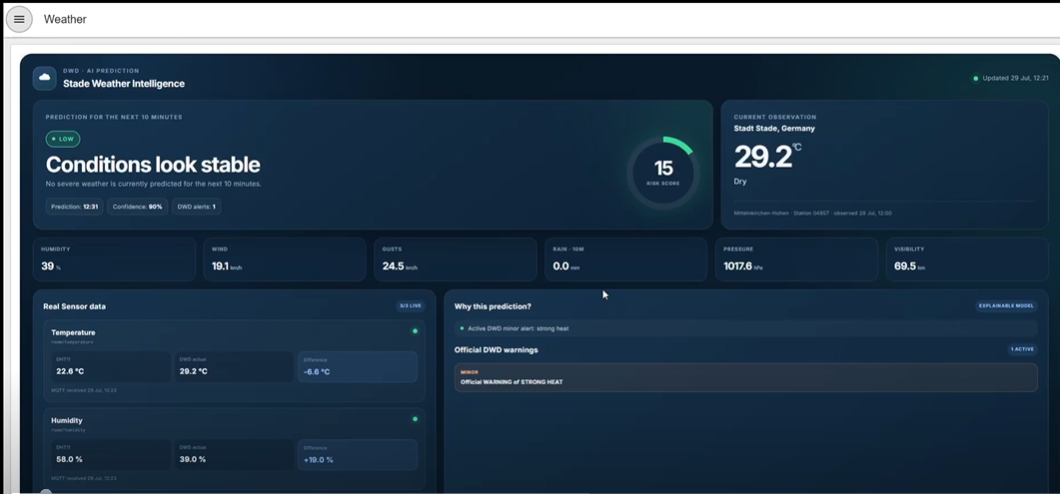

*Figure 13.4.6: Stade Weather Intelligence dashboard combining official DWD
weather information with real DHT11 sensor readings.*

The weather page extends the IIoT project from machine monitoring to
short-term environmental decision support. It combines two complementary
sources:

- **Official DWD information** supplies the Stade observation, weather
  variables and active official warnings. The screenshot shows temperature,
  humidity, wind, gusts, expected rain, pressure and visibility.
- **Real factory sensor data** supplies the local DHT11 temperature and
  humidity through the ESP8266 and HiveMQ. The dashboard compares these local
  measurements with the DWD station values and displays their differences.

In the screenshot, the local DHT11 reads **22.6 °C** while the DWD observation
is **29.2 °C**, a difference of **−6.6 °C**. Local humidity is **58%** compared
with the DWD value of **39%**, a difference of **+19 percentage points**. These
differences show why a local IIoT sensor is useful: it captures the factory's
microclimate, whereas the DWD station represents the wider outdoor area.

The prediction panel presents the model output for the next ten minutes. In
the captured example it reports **“Conditions look stable”**, a **low** risk
level, risk score **15**, confidence **90%** and one active DWD alert. The
explanation area shows why the result was produced and separately preserves
the official strong-heat warning. This separation is important: the AI
summary supports interpretation, while the official DWD warning remains the
authoritative safety information.

| Dashboard area | Meaning |
|---|---|
| Prediction and risk score | Short-term condition classification and calculated risk level |
| Confidence | How strongly the available inputs support the displayed classification |
| Current observation | Latest official DWD station condition for Stade |
| Weather variables | Humidity, wind, gusts, near-term rain, pressure and visibility used as environmental context |
| Real sensor data | Local DHT11 readings received through the IIoT system and their difference from DWD values |
| Why this prediction? | Human-readable factors that influenced the result |
| Official DWD warnings | External warning information displayed independently of the model result |

The conceptual processing relationship is:

```mermaid
flowchart TB
    DWD["DWD observation, forecast and warnings"]
    SENSOR["ESP8266 DHT11 readings<br/>published through HiveMQ"]
    PRE["Validate, normalise and align timestamps"]
    MODEL["Explainable short-term evaluation<br/>weather features and alert conditions"]
    RESULT["10-minute condition, risk score<br/>confidence and reasons"]
    DASH["Node-RED weather dashboard"]

    DWD --> PRE
    SENSOR --> PRE
    PRE --> MODEL
    MODEL --> RESULT
    RESULT --> DASH
```

*Figure 13.4.7: Conceptual data flow of the AI-assisted weather-prediction
system.*




## Appendix A — ChatGPT prompts for technical support

This appendix presents a representative selection of prompts used to obtain targeted technical support at selected stages of the IIoT Smart Factory project. It does not represent the complete development process. The system architecture, hardware assembly, programming, integration, testing and final technical decisions were completed and verified by the author. ChatGPT was used mainly to clarify complex concepts, review selected code sections, support troubleshooting and improve the presentation of the documentation. All suggestions were evaluated against the implemented system and its observed behaviour before they were adopted. Sensitive Wi-Fi, MQTT and HiveMQ credentials have been omitted.

### A.1 ESP8266 event-driven firmware integration

> Review the attached ESP8266 program and help me identify improvements to the event-driven control logic. Explain how physical push buttons and MQTT commands can share control of the conveyor and robot while retaining the existing pin assignments and topic names. Suggest a non-blocking `millis()`-based approach for debouncing, reconnection and immediate Stop commands that I can adapt and test in my implementation.

**Purpose:** To obtain guidance for refining and testing the controller while keeping the firmware implementation and validation under the author's control.

### A.2 Bidirectional MQTT communication through WebSockets

> Help me review the MQTT-related sections of my Three.js Smart Factory HTML file. Identify the existing code used for the secure WebSocket connection to HiveMQ, telemetry subscriptions, incoming-message processing and publication of robot and conveyor commands. Briefly explain these sections and suggest a topic-table format that I can use in the documentation without exposing any broker credentials.

**Purpose:** To support the author's explanation of the IIoT communication layer already implemented between the simulation, HiveMQ and the ESP8266.

### A.3 Reverse-engineering the Node-RED workflow

> Help me interpret my exported Node-RED flow JSON for documentation. Summarise the runtime paths for temperature, humidity, light intensity, robot state, conveyor-button events, simulation-topic compatibility, motor-state feedback and dashboard-state aggregation. For each path, identify the MQTT input, processing nodes and dashboard output, and clarify the difference between monitoring and control flows.

**Purpose:** To assist with presenting the author's Node-RED implementation in a concise and understandable form.

### A.4 Mermaid system and message-flow diagrams

> Using the system components and MQTT routes that I provide, suggest Mermaid diagram structures that I can adapt for my report. One diagram should show the relationships among the Three.js simulation, HiveMQ Cloud, Node-RED dashboard, ESP8266, sensors, buttons, LEDs, motor driver and motor. A second diagram should show the sequence of a remote Start command and the corresponding state feedback. Indicate suitable labels for publishers, subscribers and MQTT topics.

**Purpose:** To obtain diagramming support for visualising the system relationships and the message sequence observed during remote operation.

### A.5 Explainable AI weather-prediction system

> Review the short-term weather-prediction feature in my Smart Factory dashboard and help me explain it clearly. The feature compares official DWD observations and forecasts for Stade with local DHT11 readings received through HiveMQ. Explain appropriate ways to describe timestamp alignment, data validation, the ten-minute prediction, risk score, confidence value and human-readable reasons, while keeping official DWD warnings separate from the model output.

**Purpose:** To improve the explanation of the implemented environmental decision-support feature without presenting AI advice as an official weather warning.

### A.6 Stable WebXR floor placement and collision control

> Review the behaviour of my Smart Factory WebXR mode and help me troubleshoot unstable floor placement. Explain possible causes of plane drift after the user selects a horizontal surface, and recommend changes I can test while preserving the factory markings, hazard lines, machine layout, collision boundaries, three-times AR movement amplification and the existing desktop controls. Also advise how the Exit AR action can restore the original starting position.

**Purpose:** To obtain troubleshooting guidance for improving the author's AR implementation while preserving the existing simulation behaviour.

### A.7 Production optimisation of the Three.js simulation

> Examine my current Three.js Smart Factory application and identify areas that may affect production performance or maintainability. Suggest safe improvements for the animation loop, geometry and material reuse, event listeners and MQTT publications without changing the visible layout or operational behaviour. Provide a checklist that I can use while applying and testing the changes myself.

**Purpose:** To support the author's own optimisation and testing process without transferring responsibility for the final implementation.

### A.8 Structured Jupyter notebook documentation

> I have prepared a Jupyter notebook for my ESP8266-based IIoT Smart Factory project. Review its organisation and suggest how I can present the assignment, circuit diagram, hardware mapping and selected program sections more clearly. Check whether the Mermaid flowcharts, MQTT tables, system relationship diagrams, Node-RED summaries, remote-operation evidence and security notes follow a consistent academic structure. Also suggest improvements to the heading sequence, paragraph layout and image placement while keeping the notebook self-contained and portable.

**Purpose:** Documentation
